✅ Import สำเร็จ
กำลังดึงข้อมูลราคา...
  ✅ AOT.BK: 1752 วัน
  ✅ PTT.BK: 1752 วัน
  ✅ CPALL.BK: 1752 วัน
  ✅ SCB.BK: 949 วัน
  ✅ KBANK.BK: 1752 วัน
  ✅ BBL.BK: 1752 วัน
  ✅ KTB.BK: 1752 วัน
  ✅ SCC.BK: 1752 วัน
  ✅ GULF.BK: 233 วัน
  ✅ ADVANC.BK: 1752 วัน
  ✅ TRUE.BK: 1752 วัน
  ✅ BH.BK: 1752 วัน
  ✅ BDMS.BK: 1752 วัน
  ✅ CPN.BK: 1752 วัน
  ✅ LH.BK: 1752 วัน
  ✅ MINT.BK: 1752 วัน
  ✅ TOP.BK: 1752 วัน
  ✅ PTTEP.BK: 1752 วัน
  ✅ HMPRO.BK: 1752 วัน
  ✅ OSP.BK: 1752 วัน
  ✅ GPSC.BK: 1752 วัน
  ✅ BGRIM.BK: 1752 วัน
  ✅ RATCH.BK: 1752 วัน
  ✅ TTB.BK: 1752 วัน
  ✅ KKP.BK: 1752 วัน

✅ ดึงสำเร็จ 25 ตัว
✅ Benchmark ^SET.BK ดึงสำเร็จ

📊 ขนาดข้อมูลราคา: (1752, 25)
📅 วันแรก: 2019-01-02
📅 วันสุดท้าย: 2026-03-23
✅ คำนวณ Returns สำเร็จ (Shape: (1752, 25))

🚀 เริ่มรัน Backtest V3...
  - Equal Weight
  - Momentum (12m, top5)
  - Low Volatility (3m, top5)

📊 === สรุปเมตริกการลงทุน ===

                           Total Return (%)  CAGR (%)  Volatility (ann. %)  \
Equal Weight                          30.11 

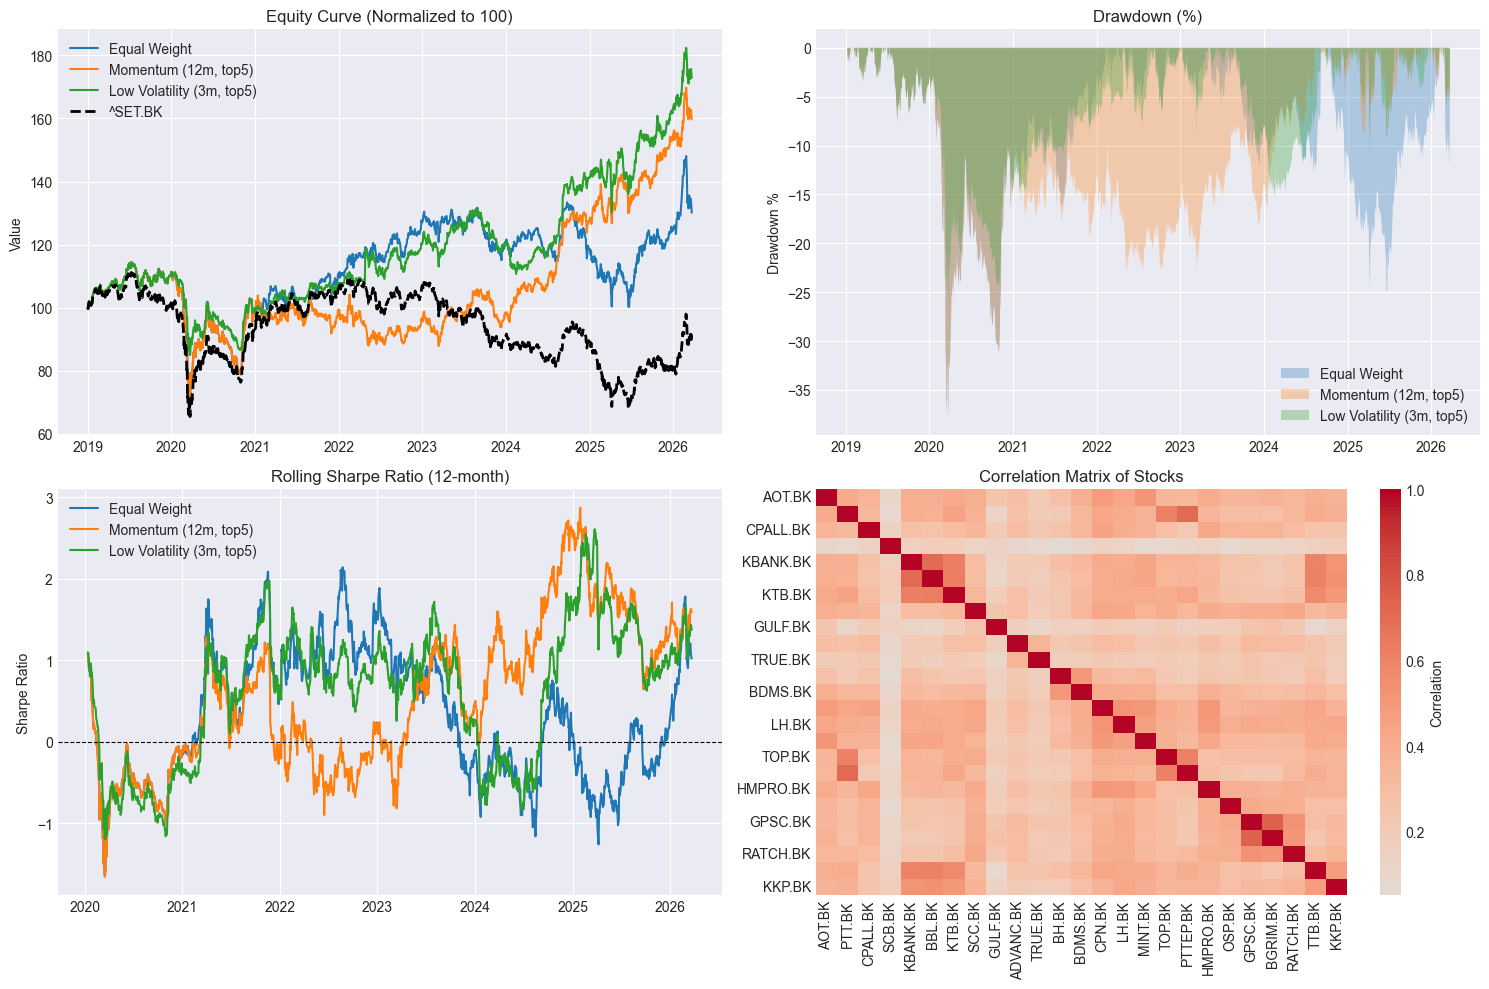


🔍 Robustness Testing: เปลี่ยน parameters ของ Momentum Strategy

ผลลัพธ์จากการเปลี่ยนแปลงพารามิเตอร์:
                        CAGR (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio
Momentum (L=126, T=3)      -2.51         -0.07            -44.84         -0.06
Momentum (L=126, T=5)       3.73          0.18            -43.03          0.09
Momentum (L=126, T=10)      4.74          0.23            -30.84          0.15
Momentum (L=252, T=3)       8.42          0.41            -37.72          0.22
Momentum (L=252, T=5)       7.00          0.35            -37.72          0.19
Momentum (L=252, T=10)      7.85          0.41            -37.72          0.21
Momentum (L=504, T=3)       6.85          0.34            -37.72          0.18
Momentum (L=504, T=5)       9.82          0.49            -37.72          0.26
Momentum (L=504, T=10)      6.79          0.35            -37.72          0.18

🦠 Stress Testing: ช่วง COVID-19 (2020)

Equal Weight:
  Total Return: -12.50%
  Max Drawdown: -35.94%
  Sha

In [3]:
# ===================================================
# Import libraries
# ===================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Import สำเร็จ")

# ===================================================
# Data loading and cleaning
# ===================================================
TICKERS = [
    "AOT.BK", "PTT.BK", "CPALL.BK", "SCB.BK", "KBANK.BK",
    "BBL.BK", "KTB.BK", "SCC.BK", "GULF.BK", "ADVANC.BK",
    "TRUE.BK", "BH.BK", "BDMS.BK", "CPN.BK", "LH.BK",
    "MINT.BK", "TOP.BK", "PTTEP.BK", "HMPRO.BK", "OSP.BK",
    "GPSC.BK", "BGRIM.BK", "RATCH.BK", "TTB.BK", "KKP.BK",
]
BENCHMARK = "^SET.BK"
START_DATE = "2019-01-01"
END_DATE = datetime.today().strftime('%Y-%m-%d')
INITIAL_CAPITAL = 1_000_000
REBALANCE_FREQ = "YE"          # Year-end rebalance
COMMISSION = 0.0015

def get_price_data(tickers, start, end):
    print("กำลังดึงข้อมูลราคา...")
    all_prices = {}
    for ticker in tickers:
        try:
            data = yf.download(ticker, start=start, end=end, progress=False)
            if len(data) > 100:
                all_prices[ticker] = data['Close'].squeeze()
                print(f"  ✅ {ticker}: {len(data)} วัน")
            else:
                print(f"  ⚠️ {ticker}: ข้อมูลน้อยเกินไป (skip)")
        except Exception as e:
            print(f"  ❌ {ticker}: {e}")
    price_df = pd.DataFrame(all_prices)
    price_df.index = pd.to_datetime(price_df.index)
    # Forward fill and backward fill to handle missing days
    price_df = price_df.ffill().bfill()
    print(f"\n✅ ดึงสำเร็จ {len(all_prices)} ตัว")
    return price_df

prices = get_price_data(TICKERS, START_DATE, END_DATE)

# Benchmark
try:
    bm_data = yf.download(BENCHMARK, start=START_DATE, end=END_DATE, progress=False)
    bm_price = bm_data['Close'].squeeze()
    print(f"✅ Benchmark {BENCHMARK} ดึงสำเร็จ")
except Exception as e:
    print(f"⚠️ ไม่สามารถดึง {BENCHMARK} ได้ (ใช้ค่าเฉลี่ยของหุ้นแทน)")
    bm_price = prices.mean(axis=1)
    BENCHMARK = "Average of Stocks (Proxy)"

print(f"\n📊 ขนาดข้อมูลราคา: {prices.shape}")
print(f"📅 วันแรก: {prices.index[0].date()}")
print(f"📅 วันสุดท้าย: {prices.index[-1].date()}")

returns = prices.pct_change()
# Keep all data, do not drop NaN yet; backtest will handle
print(f"✅ คำนวณ Returns สำเร็จ (Shape: {returns.shape})")

# ===================================================
# Backtest Engine with rebalance logic and transaction costs
# ===================================================
def backtest_v3(returns, strategy_func, rebalance='YE', initial_capital=1e6, commission=0.0015):
    """
    Backtest engine with no look-ahead bias and transaction costs.
    """
    capital = initial_capital
    dates = returns.index
    portfolio_values = []
    daily_returns = []
    turnovers = []  # record turnover at each rebalance
    
    # Determine rebalance dates: last available date of each period (e.g., year)
    rebalance_dates = set()
    if rebalance == 'YE':
        # Last trading day of each year
        for year in sorted(set(dates.year)):
            year_dates = dates[dates.year == year]
            if len(year_dates) > 0:
                rebalance_dates.add(year_dates[-1])
    elif rebalance == 'QE':
        # Last trading day of each quarter
        for year in sorted(set(dates.year)):
            for quarter in [3,6,9,12]:
                q_dates = dates[(dates.year == year) & (dates.month == quarter)]
                if len(q_dates) > 0:
                    rebalance_dates.add(q_dates[-1])
    elif rebalance == 'ME':
        # Last trading day of each month
        for year in sorted(set(dates.year)):
            for month in range(1,13):
                m_dates = dates[(dates.year == year) & (dates.month == month)]
                if len(m_dates) > 0:
                    rebalance_dates.add(m_dates[-1])
    else:
        # fallback: resample
        rebalance_dates = set(returns.resample(rebalance).last().index)
    
    # Include first date
    rebalance_dates.add(dates[0])
    
    prev_weights = {}
    current_weights = {}
    
    for i, date in enumerate(dates):
        # Data up to previous day (no look-ahead)
        past = returns.iloc[:i] if i > 0 else pd.DataFrame()
        
        # Rebalance if it's a rebalance date
        if date in rebalance_dates:
            if len(past) > 0:
                new_weights = strategy_func(past)
                # Compute turnover cost
                if prev_weights and commission > 0:
                    turnover = 0.0
                    all_tickers = set(prev_weights.keys()) | set(new_weights.keys())
                    for t in all_tickers:
                        w_old = prev_weights.get(t, 0)
                        w_new = new_weights.get(t, 0)
                        turnover += abs(w_new - w_old)
                    turnover /= 2.0
                    capital *= (1 - commission * turnover)
                    turnovers.append((date, turnover))
                else:
                    turnovers.append((date, 0.0))
                current_weights = new_weights
                prev_weights = current_weights.copy()
            else:
                # First day: equal weight
                if not current_weights:
                    if len(past) > 0:
                        current_weights = strategy_func(past)
                    else:
                        tickers = returns.columns.tolist()
                        w = 1.0 / len(tickers)
                        current_weights = {t: w for t in tickers}
                    prev_weights = current_weights.copy()
                    turnovers.append((date, 0.0))
        
        # Compute daily portfolio return
        if current_weights:
            # Get returns for the day, fill NaN with 0 (no trade)
            ret_today = returns.loc[date].fillna(0)
            # Calculate weighted sum
            port_ret = 0.0
            for ticker, w in current_weights.items():
                if ticker in ret_today.index:
                    port_ret += w * ret_today[ticker]
        else:
            port_ret = 0.0
        
        capital *= (1 + port_ret)
        portfolio_values.append(capital)
        daily_returns.append(port_ret)
    
    result = pd.DataFrame({
        'Portfolio_Value': portfolio_values,
        'Daily_Return': daily_returns
    }, index=dates)
    
    # Turnover
    turnover_df = pd.DataFrame(turnovers, columns=['Date', 'Turnover']).set_index('Date')
    result['Turnover'] = turnover_df.reindex(result.index)['Turnover'].fillna(0)
    
    return result

# ===================================================
# Strategy definitions
# ===================================================
def equal_weight_strategy(past_returns):
    """Equal weight across all stocks"""
    tickers = past_returns.columns.tolist() if len(past_returns) > 0 else []
    if not tickers:
        tickers = returns.columns.tolist()
    w = 1.0 / len(tickers)
    return {t: w for t in tickers}

def momentum_strategy(past_returns, lookback=252, top_n=5):
    """Momentum: select top_n stocks with highest cumulative return over lookback days"""
    if len(past_returns) < lookback:
        return equal_weight_strategy(past_returns)
    cum_ret = past_returns.tail(lookback).sum()
    # Replace NaN with -inf to exclude them from selection
    cum_ret = cum_ret.fillna(-np.inf)
    top = cum_ret.nlargest(top_n).index
    w = 1.0 / top_n
    return {t: w for t in top}

def low_volatility_strategy(past_returns, lookback=60, top_n=5):
    """Low volatility: select top_n stocks with lowest volatility over lookback days"""
    if len(past_returns) < lookback:
        return equal_weight_strategy(past_returns)
    vol = past_returns.tail(lookback).std()
    vol = vol.fillna(np.inf)   # exclude NaN
    low = vol.nsmallest(top_n).index
    w = 1.0 / top_n
    return {t: w for t in low}

# ===================================================
# Metrics calculation
# ===================================================
def calculate_metrics(portfolio_series, benchmark_series, rf_annual=0.02):
    """Compute advanced performance metrics"""
    # Extract daily returns
    if 'Portfolio_Value' in portfolio_series.columns:
        port_vals = portfolio_series['Portfolio_Value']
        port_ret = port_vals.pct_change().dropna()
    else:
        port_ret = portfolio_series.dropna()
    
    bm_ret = benchmark_series.pct_change().dropna()
    common_idx = port_ret.index.intersection(bm_ret.index)
    port_ret = port_ret[common_idx]
    bm_ret = bm_ret[common_idx]
    
    years = len(port_ret) / 252
    total_return = (port_vals.iloc[-1] / port_vals.iloc[0] - 1) if 'Portfolio_Value' in portfolio_series.columns else (port_ret.add(1).prod() - 1)
    cagr = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    vol_annual = port_ret.std() * np.sqrt(252)
    
    # Sharpe
    sharpe = (port_ret.mean() - rf_annual/252) / port_ret.std() * np.sqrt(252) if port_ret.std()>0 else 0
    
    # Sortino
    downside = port_ret[port_ret < 0].std() * np.sqrt(252)
    sortino = (port_ret.mean() - rf_annual/252) * 252 / downside if downside>0 else 0
    
    # Max drawdown and duration
    cum = port_vals if 'Portfolio_Value' in portfolio_series.columns else (1 + port_ret).cumprod()
    roll_max = cum.cummax()
    drawdown = (cum - roll_max) / roll_max
    max_dd = drawdown.min()
    dd_duration = (drawdown < 0).astype(int).groupby((drawdown >= 0).cumsum()).cumsum().max()
    
    # Calmar
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.inf
    
    # VaR & CVaR
    var_95 = np.percentile(port_ret, 5)
    cvar_95 = port_ret[port_ret <= var_95].mean()
    
    # Beta and Alpha
    cov = np.cov(port_ret, bm_ret)[0,1]
    var_bm = bm_ret.var()
    beta = cov / var_bm if var_bm>0 else 0
    alpha_annual = (port_ret.mean() - rf_annual/252) - beta * (bm_ret.mean() - rf_annual/252)
    alpha_annual *= 252
    
    # Information Ratio
    active_ret = port_ret - bm_ret
    tracking_error = active_ret.std() * np.sqrt(252)
    info_ratio = active_ret.mean() * 252 / tracking_error if tracking_error>0 else 0
    
    # Up/Down Capture
    up = bm_ret > 0
    down = bm_ret < 0
    up_capture = port_ret[up].mean() / bm_ret[up].mean() if bm_ret[up].mean() != 0 else 0
    down_capture = port_ret[down].mean() / bm_ret[down].mean() if bm_ret[down].mean() != 0 else 0
    
    metrics = {
        'Total Return (%)': total_return * 100,
        'CAGR (%)': cagr * 100,
        'Volatility (ann. %)': vol_annual * 100,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown (%)': max_dd * 100,
        'Max DD Duration (days)': dd_duration,
        'Calmar Ratio': calmar,
        'VaR (95%) (%)': var_95 * 100,
        'CVaR (95%) (%)': cvar_95 * 100,
        'Beta': beta,
        'Alpha (ann. %)': alpha_annual * 100,
        'Information Ratio': info_ratio,
        'Up Capture (%)': up_capture * 100,
        'Down Capture (%)': down_capture * 100,
    }
    return metrics

def calculate_turnover_stats(result_df):
    turnover = result_df['Turnover']
    avg_turnover = turnover[turnover>0].mean() if (turnover>0).any() else 0
    annual_turnover = turnover.sum() * (252/len(result_df))
    return {
        'Avg Turnover per Trade (%)': avg_turnover * 100,
        'Annual Turnover (%)': annual_turnover * 100
    }

# ===================================================
# Run backtest for three strategies
# ===================================================
strategies = {
    'Equal Weight': lambda past: equal_weight_strategy(past),
    'Momentum (12m, top5)': lambda past: momentum_strategy(past, lookback=252, top_n=5),
    'Low Volatility (3m, top5)': lambda past: low_volatility_strategy(past, lookback=60, top_n=5),
}

print("\n🚀 เริ่มรัน Backtest V3...")
results = {}
for name, strat in strategies.items():
    print(f"  - {name}")
    res = backtest_v3(returns, strat, rebalance=REBALANCE_FREQ,
                      initial_capital=INITIAL_CAPITAL, commission=COMMISSION)
    results[name] = res

# ===================================================
# Display metrics summary
# ===================================================
metrics_summary = {}
for name, res in results.items():
    m = calculate_metrics(res, bm_price, rf_annual=0.02)
    t = calculate_turnover_stats(res)
    m.update(t)
    metrics_summary[name] = m

summary_df = pd.DataFrame(metrics_summary).T
print("\n📊 === สรุปเมตริกการลงทุน ===\n")
print(summary_df.round(2))

# ===================================================
# Visualization
# ===================================================
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Equity curve
ax1 = axes[0,0]
for name, res in results.items():
    normalized = res['Portfolio_Value'] / res['Portfolio_Value'].iloc[0] * 100
    ax1.plot(res.index, normalized, label=name)
ax1.plot(bm_price.index, bm_price / bm_price.iloc[0] * 100, 'k--', label=BENCHMARK, linewidth=2)
ax1.set_title('Equity Curve (Normalized to 100)')
ax1.set_ylabel('Value')
ax1.legend()
ax1.grid(True)

# Drawdown
ax2 = axes[0,1]
for name, res in results.items():
    cum = res['Portfolio_Value']
    roll_max = cum.cummax()
    dd = (cum - roll_max) / roll_max * 100
    ax2.fill_between(res.index, dd, 0, alpha=0.3, label=name)
ax2.set_title('Drawdown (%)')
ax2.set_ylabel('Drawdown %')
ax2.legend()
ax2.grid(True)

# Rolling Sharpe (12m)
ax3 = axes[1,0]
window = 252
for name, res in results.items():
    port_ret = res['Daily_Return'].dropna()
    rolling_sharpe = port_ret.rolling(window).apply(
        lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else 0, raw=True)
    ax3.plot(rolling_sharpe.index, rolling_sharpe, label=name)
ax3.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax3.set_title('Rolling Sharpe Ratio (12-month)')
ax3.set_ylabel('Sharpe Ratio')
ax3.legend()
ax3.grid(True)

# Heatmap correlation of returns
ax4 = axes[1,1]
corr = returns.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax4, cbar_kws={'label': 'Correlation'})
ax4.set_title('Correlation Matrix of Stocks')

plt.tight_layout()
plt.show()

# ===================================================
# Robustness testing
# ===================================================
print("\n🔍 Robustness Testing: เปลี่ยน parameters ของ Momentum Strategy")
lookbacks = [126, 252, 504]   # 6, 12, 24 months
top_ns = [3, 5, 10]
results_robust = {}

for lookback in lookbacks:
    for top_n in top_ns:
        name = f"Momentum (L={lookback}, T={top_n})"
        # Use closure to capture parameters
        strat = lambda past, l=lookback, t=top_n: momentum_strategy(past, lookback=l, top_n=t)
        res = backtest_v3(returns, strat, rebalance=REBALANCE_FREQ,
                          initial_capital=INITIAL_CAPITAL, commission=COMMISSION)
        metrics = calculate_metrics(res, bm_price, rf_annual=0.02)
        results_robust[name] = metrics

robust_df = pd.DataFrame(results_robust).T
print("\nผลลัพธ์จากการเปลี่ยนแปลงพารามิเตอร์:")
print(robust_df[['CAGR (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Calmar Ratio']].round(2))

# ===================================================
# CELL 10: Stress Testing – แยกช่วง COVID-19 
# ===================================================
covid_start = '2020-01-01'
covid_end = '2020-12-31'
print("\n🦠 Stress Testing: ช่วง COVID-19 (2020)")

# ตรวจสอบว่ามีข้อมูลในช่วงนี้หรือไม่
has_covid = any(((res.index >= covid_start) & (res.index <= covid_end)).any() for res in results.values())
if not has_covid:
    print("⚠️ ไม่มีข้อมูลในช่วง COVID-19 ในผลลัพธ์ backtest")
else:
    for name, res in results.items():
        covid_mask = (res.index >= covid_start) & (res.index <= covid_end)
        if covid_mask.any():
            port_covid = res.loc[covid_mask]
            # align benchmark index กับ res.index ก่อนกรอง
            bm_aligned = bm_price.reindex(res.index)
            bm_covid = bm_aligned.loc[covid_mask]
            metrics_covid = calculate_metrics(port_covid, bm_covid, rf_annual=0.02)
            print(f"\n{name}:")
            print(f"  Total Return: {metrics_covid['Total Return (%)']:.2f}%")
            print(f"  Max Drawdown: {metrics_covid['Max Drawdown (%)']:.2f}%")
            print(f"  Sharpe: {metrics_covid['Sharpe Ratio']:.2f}")